In [3]:
import numpy as np
import torch 
import torch.nn as nn 
import scipy.io 
import torch
import math
import matplotlib.pyplot as plt


In [4]:
data = scipy.io.loadmat('/Users/ramtarun/Desktop/Cambridge/Indirect-Noise-in-Nozzles/Data/Data_PINN_ff0.01He0N551_subsonic.mat')
 

In [6]:
eta = data['eta']
pi_p = data['pi_p']
pi_m = data['pi_m']
sig = data['sig']

N1 = eta.shape[1]

U = np.zeros((N1,4),dtype=float)
U[:,0] = eta
U[:,1] = pi_p
U[:,2] = pi_m
U[:,3] = sig

In [18]:
D = data['D']
M = data['M']
u = data['ubar']
dMdx = data['dMdx']
dudx = data['dudx']
alpha = data['alp']
eta1 = data['eta']    

#print(N1)

meanflow = np.zeros((N1,7),dtype=float)
meanflow[:,0] = D
meanflow[:,1] = M
meanflow[:,2] = u
meanflow[:,3] = dMdx
meanflow[:,4] = dudx
meanflow[:,5] = alpha
meanflow[:,6] = eta1

meanflow = torch.from_numpy(meanflow)
#print(meanflow)

In [52]:
he = torch.tensor([0.01])
HE = np.tile(he, (1,N1)) # N x T
He = HE.flatten()[:,None]
ETA = eta.flatten()[:, None]
He_train = torch.from_numpy(He).type(torch.float32)
ETA_train = torch.from_numpy(ETA).type(torch.float32)



UU = torch.from_numpy(U[:, 1:4]).type(torch.float32)

ETA_train.requires_grad = True
#print(UU)

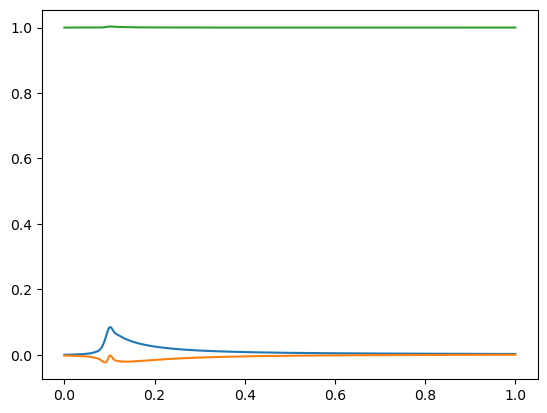

In [20]:
plt.plot(ETA, UU)

In [39]:
def RHS(x,y, baseflow):
    eta = x
    pi_p, pi_m, sig = torch.unbind(y ,axis=1)
    D = baseflow[:, 0]
    M = baseflow[:, 1]
    u = baseflow[:,2 ]
    dMdx = baseflow[:, 3]
    dudx = baseflow[:, 4]
    alpha = baseflow[:, 5 ]
    eta1 = baseflow[:, 6]
    
    He = 0# constant input
    gamma = 1.4#constant
    Msq = torch.square(M)
    f = 0.01 #Variable (parameter of the network)
    Lambda = 1 + Msq * (gamma-1)/2
    zeta = f*gamma*Msq - 2* torch.tan(alpha)

    C1= ( (gamma - 1)* (1-Msq)*f) / (2*Lambda*zeta)
    Ca = -C1*M*u*dMdx* (2- (2*Msq/(1-Msq)) - (2*gamma*Msq* (-2*f*Lambda - (gamma-1)/gamma *zeta) / (2*Lambda*zeta) ))
    Ff = - (dudx + (4*f*u/ (2*D) ))
    denom = (M**2*u - u + C1*Msq *u + C1*Msq*Msq*gamma*u) #M**4
    vrh_p = M* (2* (1-M) + C1*M* (M-2+M*gamma* (1-2*M) )) / (2 * denom)
    vrh_m = -M* (2* (1+M) + C1*M* (M+2+M*gamma* (1+2*M) )) / (2 *denom)
    vkp_p = Msq*C1 * (2+M* (gamma-1)) / (2*denom)
    vkp_m = Msq*C1 * (2-M* (gamma-1) ) / (2* denom)
    vth_p = C1*M* (M* (1+gamma) + M**2* (1-gamma) - 2) /denom
    vth_m = C1*M* (M* (1+gamma) - M**2* (1-gamma) + 2) / denom
    vsig = - (C1*Msq* (1+gamma*Msq) + Msq - 1) / denom
    calM = dMdx/ (2*M)
    kp_p = (gamma - 1) + (2/M)
    kp_m = (gamma - 1) - (2/M)
    Gm_p = M* (Ca* (M + 1) + Ff*M* (C1 *gamma*M*Msq + M + (1 - C1*Msq))) / (2 * denom)
    Gm_m = M* (Ca* (M - 1) - Ff*M* (C1*gamma*M*Msq + M - (1 - C1*Msq) )) / (2 *denom)
    Ups = (Ca* (Msq - 1) - C1*Ff*Msq*Msq * (1+gamma)) /denom    

    eq1 = - (Gm_m*kp_m + calM)*pi_p + (Gm_m*kp_p + calM)*pi_m - Gm_m*sig
    eq2 = - (Gm_p*kp_m - calM)*pi_p - (Gm_p*kp_p + calM) *pi_m - Gm_m*sig
    eq3 = - (Ups*kp_m) *pi_p - (Ups*kp_p)*pi_m - (Ups)*sig

    return torch.stack([-eq1, -eq2, -eq3], axis=1)

print(RHS(eta, UU, meanflow))

tensor([[ 2.4709e-02, -2.2883e-02,  2.3129e-05],
        [ 2.6618e-02, -2.4692e-02,  2.3939e-05],
        [ 2.8841e-02, -2.6800e-02,  2.4776e-05],
        ...,
        [-2.4504e-03,  2.3620e-03, -2.4325e-06],
        [-2.4188e-03,  2.3309e-03, -2.4309e-06],
        [-2.3877e-03,  2.3004e-03, -2.4289e-06]], dtype=torch.float64)


In [78]:
# Hyperparameters Initialization for tuning
epochs=2000
learning_rate=1e-3
layers = np.array([2, 20, 20, 20, 20, 20, 20, 20, 20, 3]) # hidden layers
N_train = eta.shape[1]
N_train

551

In [79]:
# Neural Network for Predicting the pi+, pi-, and si.

class NN(nn.Module):
    def __init__(self, He, Eta, layers):
        super().__init__()

        'activation function'
        self.activation = nn.Tanh()
    
        'Initialize neural network as a list using nn.Modulelist'  
        self.linears = nn.ModuleList([nn.Linear(layers[i], layers[i+1]) for i in range(len(layers)-1)])
    
        'Xavier Normal Initialization'
        for i in range(len(layers)-1):
            
            nn.init.xavier_normal_(self.linears[i].weight.data, gain=1.0)
            
            # set biases to zero
            nn.init.zeros_(self.linears[i].bias.data)

        
        X = torch.cat([He, Eta],1)
    def forward(self, X):
        if torch.is_tensor(X) != True:         
            X = torch.from_numpy(X)   
        a = X.float()
        for i in range(len(layers) - 2):
            z = self.linears[i](a)
            a = self.activation(z)
        a = self.linears[-1](a)
        return a

In [80]:
# Physics informed Neural Network 
f = 0.01

class PINN(nn.Module):
    def __init__(self,He, Eta, uu, meanflow, layers):
        super().__init__()
        self.loss_function = nn.MSELoss(reduction ='mean')

        'Initialize our new parameters i.e.f (Inverse problem)' 
        self.f = torch.tensor([f], requires_grad=True).type(torch.float32)
        'Register f to optimize'
        self.f = nn.Parameter(self.f)
        'Initialize iterator'
        self.iter = 0
        'Call our DNN'
        self.dnn = NN(He, Eta, layers)
        'Register our new parameter'
        self.dnn.register_parameter('f', self.f)  
        
        self.meanflow = meanflow
        self.UU = uu
        X = torch.cat([He, Eta],1)
          
    def loss_data(self, X):
        g = torch.clone(X)
        R = self.dnn(g)
        loss_u = self.loss_function(R, self.UU)
        return loss_u
    
    def loss_residual(self, Eta, X):
        g = torch.clone(X)
        R = self.dnn(g)
        GR = RHS(Eta, R, self.meanflow)
        dr_dn = torch.autograd.grad(R,Eta,torch.ones_like(R), retain_graph=True, create_graph=True)[0]
        pde = dr_dn - GR
        null = torch.zeros(Eta.shape[0],1)#to minimize function
        loss_r = self.loss_function(pde.float(), null.float())
        return loss_r
    
    def Loss(self, X, Eta):
        loss_data = self.loss_data(X)
        loss_residual = self.loss_residual(Eta, X)
        return loss_data + loss_residual

In [81]:
N = torch.cat([He_train, ETA_train],1)

In [82]:
PINN_model = PINN(He_train, ETA_train, UU, meanflow, layers)
params = list(PINN_model.parameters())
optimizer = torch.optim.Adam(PINN_model.parameters(),lr=learning_rate,amsgrad=False)

In [86]:
for i in range(epochs):
    if i==0:
      print("Training Loss-----Test Loss")
    loss = PINN_model.Loss(N, ETA_train)# use mean squared error
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if i%(epochs/10)==0:
       with torch.no_grad():
          print(loss.detach().numpy())
    

Training Loss-----Test Loss
0.02180057


/opt/anaconda3/envs/Pytorch/lib/python3.10/site-packages/torch/nn/modules/loss.py:536: UserWarning: Using a target size (torch.Size([551, 1])) that is different to the input size (torch.Size([551, 3])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


0.021673419
0.022617927
0.021704387
0.02153634
0.021505091
0.02150193
0.021419123
0.02139318
0.021341145
